# Raspberry Maquila — Starter
Created: 2025-11-11 05:37

## Notebook Purpose
This notebook builds weekly cash flows (36 prod + 12 idle weeks), computes Traditional NPV,
and values operational flexibility (real options) via Monte Carlo.


## 1) Context and Given Data
- Products: 80/20, Crumble, Block.
- Fixed labor: 40,000 MXN/week (all 52 weeks).
- Yield ratio in [0.50, 0.82] (assume Beta on this range).


## 2) Assumptions & Imports

In [ ]:
import numpy as np, pandas as pd, math
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
WEEKS_PROD, WEEKS_IDLE, WEEKS_YEAR = 36, 12, 48

r_eff = 0.12; r_cont = math.log(1+r_eff); disc_week = math.exp(-r_cont/52.0)
fixed_labor_week = 40_000.0
capacity_min_tons, capacity_max_tons = 25.0, 40.0
baseline_throughput_tons = 32.5
price_8020, price_crum, price_block = 65.0, 30.0, 17.0
proc_8020,  proc_crum,  proc_block  = 13.0, 11.0, 7.0
fruit_cost_8020, fruit_cost_crum, fruit_cost_block = 25.0, 20.0, 20.0
p_8020, p_crum, p_block = 0.70, 0.24, 0.06
yield_min, yield_max = 0.50, 0.82
yield_alpha, yield_beta = 3.0, 2.5

def draw_yield(n=1, rng=rng):
    y = rng.beta(yield_alpha, yield_beta, size=n)
    return yield_min + (yield_max-yield_min)*y

def discounted(v,w): 
    return v*(math.exp(-r_cont/52.0)**w)

def weekly_product_split(kg_incoming, y):
    fin_8020  = kg_incoming*p_8020*y
    fin_crum  = kg_incoming*p_crum*y
    fin_block = kg_incoming*p_block*y
    return fin_8020, fin_crum, fin_block

def weekly_revenue(f8020, fcrum, fblock):
    return f8020*price_8020 + fcrum*price_crum + fblock*price_block

def weekly_process_cost(f8020, fcrum, fblock):
    return f8020*proc_8020 + fcrum*proc_crum + fblock*proc_block

def weekly_fruit_cost(kg_incoming):
    return (kg_incoming*p_8020*fruit_cost_8020
          + kg_incoming*p_crum*fruit_cost_crum
          + kg_incoming*p_block*fruit_cost_block)


## 3) Traditional NPV (Deterministic)

In [24]:
import numpy_financial as npf

# --- Parámetros básicos ---
initial_inv = 4_000_000     # inversión inicial
weeks = np.arange(WEEKS_YEAR)
r_annual = 0.12
r_weekly = (1 + r_annual) ** (1/52) - 1  # tasa efectiva semanal

# --- Estructura base ---
y_mean = (yield_min + yield_max)/2
df = pd.DataFrame({'week': weeks})
df['is_prod'] = (df['week'] < WEEKS_PROD).astype(int)
df['tons']  = df['is_prod'] * baseline_throughput_tons
df['kg_in'] = df['tons'] * 1000.0
df['yield'] = y_mean

# --- Cálculos de producción y flujos ---
f8020, fcrum, fblock = weekly_product_split(df['kg_in'], df['yield'])
df['rev']   = weekly_revenue(f8020, fcrum, fblock)
df['proc']  = weekly_process_cost(f8020, fcrum, fblock)
df['fruit'] = df['kg_in'].apply(weekly_fruit_cost)
df['fixed'] = fixed_labor_week * (df['is_prod'] == 0).astype(int)

# --- Flujo semanal y flujo total ---
df['CF'] = df['rev'] - df['proc'] - df['fruit'] - df['fixed']
cash_flows = df['CF'].to_list()
cash_flows.insert(0, -initial_inv)  # agrega la inversión inicial en semana 0

# --- NPV e IRR con numpy-financial ---
npv_value = npf.npv(r_weekly, cash_flows)
irr_value = npf.irr(cash_flows)

print(f"Weekly discount rate: {r_weekly:.6f}")
print(f"NPV (weekly discounted): {npv_value:,.2f} MXN")
print(f"IRR (weekly): {irr_value:.4%}")
print(f"IRR (annualized): {(1+irr_value)**52 - 1:.2%}")

cash_flows

Weekly discount rate: 0.002182
NPV (weekly discounted): -20,469.74 MXN
IRR (weekly): 0.1852%
IRR (annualized): 10.10%


[-4000000,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 127711.99999999977,
 -40000.0,
 -40000.0,
 -40000.0,
 -40000.0,
 -40000.0,
 -40000.0,
 -40000.0,
 -40000.0,
 -40000.0,
 -40000.0,
 -40000.0,
 -40000.0]

### Plot CF

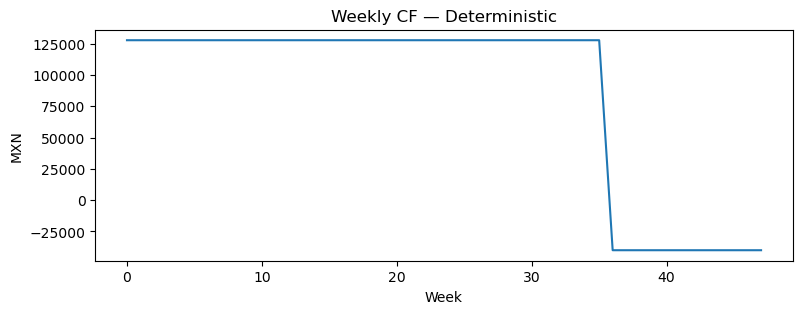

In [25]:
plt.figure(figsize=(9,3))
plt.plot(df['week'], df['CF'])
plt.title('Weekly CF — Deterministic')
plt.xlabel('Week')
plt.ylabel('MXN')
plt.show()

## 4) Real Options — Weekly Flex (0–40 t)

In [26]:
def weekly_cf_given_throughput(t_tons, y):
    kg = t_tons*1000.0
    f8020, fcrum, fblock = weekly_product_split(kg, y)
    return weekly_revenue(f8020,fcrum,fblock) - weekly_process_cost(f8020,fcrum,fblock) - weekly_fruit_cost(kg) - fixed_labor_week

def sim_fixed(baseline=32.5, seed=123):
    r = np.random.default_rng(seed); pv=0.0
    for w in range(WEEKS_YEAR):
        if w < WEEKS_PROD:
            y = draw_yield(1, r)[0]
            pv += discounted(weekly_cf_given_throughput(baseline, y), w)
        else:
            pv += discounted(-fixed_labor_week, w)
    return pv

def sim_flex(cand=np.linspace(0,40,41), seed=123):
    r = np.random.default_rng(seed); pv=0.0
    for w in range(WEEKS_YEAR):
        if w < WEEKS_PROD:
            y = draw_yield(1, r)[0]
            cfs = [weekly_cf_given_throughput(t, y) for t in cand]
            pv += discounted(max(cfs), w)
        else:
            pv += discounted(-fixed_labor_week, w)
    return pv

N=800
cand = np.linspace(0,40,41)
pv_fix = np.array([sim_fixed(seed=1000+i) for i in range(N)])
pv_flex= np.array([sim_flex(cand=cand, seed=2000+i) for i in range(N)])
import pandas as pd
res = pd.DataFrame({'PV_fixed': pv_fix, 'PV_flex': pv_flex}); res['Uplift']=res['PV_flex']-res['PV_fixed']
print('Mean PV fixed :', f'{res.PV_fixed.mean():,.0f}','MXN')
print('Mean PV flex  :', f'{res.PV_flex.mean():,.0f}','MXN')
print('Mean uplift   :', f'{res.Uplift.mean():,.0f}','MXN')
res.head()


Mean PV fixed : 3,266,357 MXN
Mean PV flex  : 4,488,202 MXN
Mean uplift   : 1,221,845 MXN


,PV_fixed,PV_flex,Uplift
0,3.366674e+06,4.601142e+06,1.234468e+06
1,3.192605e+06,3.769646e+06,5.770413e+05
2,3.096275e+06,6.450196e+06,3.353921e+06
3,3.019286e+06,5.221395e+06,2.202109e+06
4,3.495314e+06,3.979526e+06,4.842120e+05


### Histograms

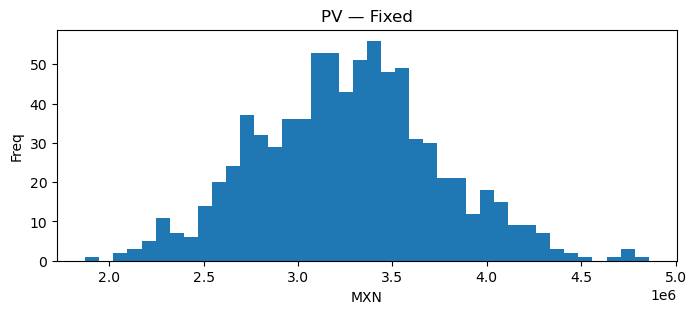

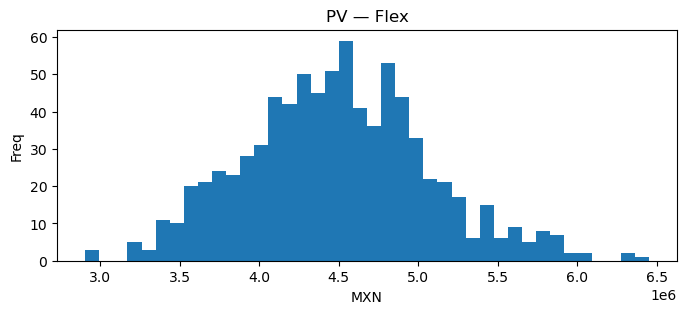

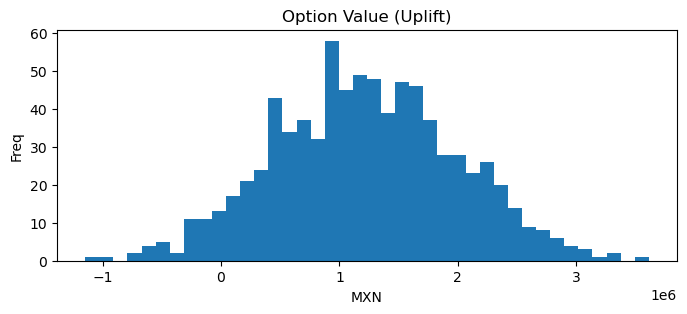

In [6]:
plt.figure(figsize=(8,3))
plt.hist(res['PV_fixed'], bins=40)
plt.title('PV — Fixed')
plt.xlabel('MXN')
plt.ylabel('Freq')
plt.show()

plt.figure(figsize=(8,3))
plt.hist(res['PV_flex'],  bins=40)
plt.title('PV — Flex')
plt.xlabel('MXN')
plt.ylabel('Freq')
plt.show()

plt.figure(figsize=(8,3))
plt.hist(res['Uplift'],   bins=40)
plt.title('Option Value (Uplift)')
plt.xlabel('MXN')
plt.ylabel('Freq')
plt.show()